<a href="https://colab.research.google.com/github/yerim823/yerim/blob/main/2026_%EC%9C%A1%EA%B5%B0_AI%EC%86%8C%EC%96%91%EA%B5%90%EC%9C%A1_3%EC%9D%BC%EC%B0%A8_%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎖️ 2026년 부대 맞춤형 AI·SW 소양교육
## 육군 직무보수교육 - **3일차 실습 노트북**

> **Ⅲ. 데이터 분석 및 가공**
>  
> - 데이터 그룹화 (`groupby`) & 집계 함수
> - `agg()` 다중·사용자 정의 집계
> - 피벗 테이블 (`pivot_table`) & 교차 분석 (`crosstab`)
> - 통계적 요약 (`describe`, 분포 분석, IQR)
> - 상관관계 분석 (`corr`, 히트맵)
> - Matplotlib 기초 (꺾은선·막대·산점도·히스토그램)
> - Seaborn 통계 시각화 (box·violin·heatmap·pairplot)
> - 종합 대시보드 구축

---

### 📌 노트북 사용법
1. 각 셀을 순서대로 실행합니다. (`Shift + Enter`)
2. 💻 **실습 예제** 셀은 직접 실행하며 결과를 확인합니다.
3. 🔥 **실습문제** 셀에 직접 답안 코드를 작성해 보세요.
4. ✅ **정답 코드** 셀은 스스로 풀어본 뒤 확인하세요.

### 💡 3일차 핵심 키워드
> **"데이터는 숫자가 아니라 스토리다"**  
> 그룹화 → 피벗 → 상관분석 → 시각화로 데이터에 숨은 **인사이트**를 발견합니다.

---

# 🛠️ Chapter 0. 환경 구성 및 데이터 준비

## 0-1. 라이브러리 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f"pandas    : {pd.__version__}")
print(f"numpy     : {np.__version__}")
print(f"matplotlib: {mpl.__version__}")
print(f"seaborn   : {sns.__version__}")

pandas    : 2.2.2
numpy     : 2.0.2
matplotlib: 3.10.0
seaborn   : 0.13.2


## 0-2. 한글 폰트 설정 (Colab 그래프 한글 깨짐 방지)

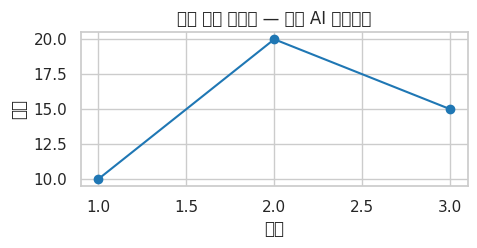

✅ 한글 폰트 및 스타일 설정 완료


In [2]:
# 나눔고딕 설치
!apt-get install -qq fonts-nanum > /dev/null 2>&1

import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

sns.set_style('whitegrid')
sns.set_context('notebook')

# 테스트
plt.figure(figsize=(5, 2))
plt.title("한글 폰트 테스트 — 육군 AI 소양교육")
plt.plot([1, 2, 3], [10, 20, 15], marker='o')
plt.xlabel("회차"); plt.ylabel("점수")
plt.show()
print("✅ 한글 폰트 및 스타일 설정 완료")

## 0-3. 실습용 훈련 데이터 생성

**150명 규모의 부대 훈련 데이터**를 생성합니다. (3일차는 통계·시각화 중심이라 데이터가 많아야 의미 있음)

**컬럼 구성**
- `이름` · `계급`(이병/일병/상병/병장) · `부대`(1~3중대)
- `나이`(19~25) · `복무일수`(1~730일) · `키`(cm) · `몸무게`(kg)
- `훈련점수`(0~100) · `체력점수`(0~100) · `입대일`

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
N = 150

# 이름 생성용 풀
성씨  = ["김", "이", "박", "최", "정", "강", "조", "윤", "장", "임", "한", "오", "서", "신", "권"]
이름풀 = ["철수", "영희", "민준", "수진", "태양", "지훈", "서연", "도현", "은비", "재혁",
        "소희", "현우", "유진", "동욱", "나라", "수민", "지성", "우식", "민아", "우진"]

# 계급·부대·훈련점수 생성 (계급이 높을수록 평균 점수가 높도록)
ranks  = np.random.choice(["이병", "일병", "상병", "병장"],
                          N, p=[0.30, 0.30, 0.25, 0.15])
units  = np.random.choice(["1중대", "2중대", "3중대"], N, p=[0.40, 0.35, 0.25])

# 계급별 기본 점수 설정 (계급이 높을수록 숙련도 UP)
rank_base = {"이병": 75, "일병": 80, "상병": 85, "병장": 90}
훈련점수 = np.array([rank_base[r] + np.random.normal(0, 6) for r in ranks]).clip(40, 100)

# 체력점수는 훈련점수와 강한 양의 상관 (r ≈ 0.8)
체력점수 = (0.75 * 훈련점수 + 0.25 * np.random.normal(85, 8, N)).clip(40, 100)

# 복무일수: 계급에 비례
rank_days = {"이병": (1, 180), "일병": (180, 360), "상병": (360, 540), "병장": (540, 730)}
복무일수 = np.array([np.random.randint(*rank_days[r]) for r in ranks])

data = pd.DataFrame({
    "이름":     [np.random.choice(성씨) + np.random.choice(이름풀) for _ in range(N)],
    "계급":     ranks,
    "부대":     units,
    "나이":     np.random.randint(19, 26, N),
    "복무일수": 복무일수,
    "키":       np.round(np.random.normal(173, 6, N), 1),
    "몸무게":   np.round(np.random.normal(70, 8, N), 1),
    "훈련점수": 훈련점수.round(1),
    "체력점수": 체력점수.round(1),
    "입대일":   pd.date_range('2023-01-01', periods=N, freq='D').astype(str)
})

# 저장
data.to_csv('/content/training.csv', index=False, encoding='utf-8-sig')

print(f"✅ 훈련 데이터 생성 완료: {data.shape[0]}명 × {data.shape[1]}컬럼")
print(f"   계급 분포: {dict(data['계급'].value_counts())}")
print(f"   부대 분포: {dict(data['부대'].value_counts())}")
data.head()

---
# 📊 Chapter 1. 데이터 그룹화 (`groupby`) 기초

## 1-1. Groupby 란?
> **특정 기준(컬럼)으로 데이터를 묶고 → 그룹별로 집계 함수를 적용**
> - SQL의 `GROUP BY`, Excel의 분류별 합계와 **동일한 개념**
> - 3단계 원리: **Split (분리) → Apply (적용) → Combine (결합)**

```
   ✂️ Split          ⚙️ Apply        🔗 Combine
   ─────────         ────────       ──────────
   기준컬럼으로   →  각 그룹에     →  결과를 합쳐
   데이터 분리       집계 함수 적용    새 DataFrame 생성
```

## 1-2. 기본 문법
```python
df.groupby('기준컬럼')['대상컬럼'].집계함수()
```

In [ ]:
df = pd.read_csv('/content/training.csv')

# ① 계급별 평균 훈련점수
print("[ 계급별 평균 훈련점수 ]")
print(df.groupby('계급')['훈련점수'].mean().round(1))

In [ ]:
# ② 부대별 인원수
print("[ 부대별 인원 수 ]")
print(df.groupby('부대').size())

# ③ 계급별 체력점수 합계
print("\n[ 계급별 체력점수 합계 ]")
print(df.groupby('계급')['체력점수'].sum().round(0))

## 1-3. 집계 함수 8종 정리

| 함수 | 의미 | 예시 |
|---|---|---|
| `.mean()` | 평균 | 이병: 78.5, 상병: 89.5 |
| `.sum()` | 합계 | 1중대: 470 |
| `.count()` | 개수 (NaN 제외) | 이병: 45 |
| `.size()` | 행 수 (NaN 포함) | 이병: 45 |
| `.max()` | 최대값 | 병장: 100 |
| `.min()` | 최소값 | 이병: 52 |
| `.median()` | 중앙값 | 1중대: 87 |
| `.std()` | 표준편차 | 이병: 8.2 |

In [ ]:
# 여러 컬럼 동시 집계
result = df.groupby('계급')[['훈련점수', '체력점수']].mean().round(1)
print("[ 계급별 훈련·체력 평균 ]")
print(result)

In [ ]:
# 조건부 그룹화: 70점 이상인 병사만 필터 후 계급별 평균
filtered = df[df['훈련점수'] >= 70].groupby('계급')['훈련점수'].mean().round(1)
print("[ 70점 이상 병사의 계급별 평균 ]")
print(filtered)

# 1중대만 계급별 평균
ch1 = df[df['부대'] == '1중대'].groupby('계급')['훈련점수'].mean().round(1)
print("\n[ 1중대만 계급별 평균 훈련점수 ]")
print(ch1)

## 1-4. `reset_index()` — 결과를 DataFrame으로 변환

In [ ]:
# 기본 groupby 결과는 Series (계급이 index)
s = df.groupby('계급')['훈련점수'].mean()
print(f"기본 결과 타입: {type(s).__name__}")
print(s, "\n")

# reset_index()로 DataFrame 변환
df_result = df.groupby('계급')['훈련점수'].mean().reset_index(name='훈련평균').round(1)
print(f"reset_index 후: {type(df_result).__name__}")
print(df_result)

---
### 🔥 실습문제 1
`df` 데이터에 대해 다음을 수행하세요.

1. **부대별** 평균 훈련점수·체력점수 출력 (소수점 1자리)
2. **계급별** 최고점 (`max`) 과 최저점 (`min`) 동시 출력
3. **체력점수 90점 이상** 인 병사만 필터링한 뒤, **부대별 인원수** 출력
4. 계급별 평균 훈련점수를 **DataFrame 형태**로 만들고 **내림차순 정렬**

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 부대별 평균
print("[ 1. 부대별 훈련·체력 평균 ]")
print(df.groupby('부대')[['훈련점수', '체력점수']].mean().round(1))

# 2) 계급별 max/min
print("\n[ 2. 계급별 max/min ]")
print(df.groupby('계급')['훈련점수'].agg(['max', 'min']).round(1))

# 3) 체력 90 이상 → 부대별 인원
print("\n[ 3. 체력점수 90+ 부대별 인원 ]")
print(df[df['체력점수'] >= 90].groupby('부대').size())

# 4) DataFrame + 내림차순
print("\n[ 4. 계급별 평균 훈련점수 내림차순 ]")
result = (df.groupby('계급')['훈련점수']
            .mean()
            .reset_index(name='평균점수')
            .sort_values('평균점수', ascending=False)
            .round(1))
print(result.to_string(index=False))

---
# ⚙️ Chapter 2. `agg()` — 다중·사용자 정의 집계

> `agg()` = 한 번에 **여러 집계 함수** 를 적용하거나, **컬럼마다 다른 함수** 를 지정할 수 있는 강력한 집계 메서드

## 2-1. 4가지 사용 패턴

### ① 리스트로 다중 집계

In [ ]:
# 계급별 훈련점수의 평균/최대/최소/표준편차
result = df.groupby('계급')['훈련점수'].agg(['mean', 'max', 'min', 'std']).round(2)
print("[ 계급별 훈련점수 종합 통계 ]")
print(result)

### ② 딕셔너리로 컬럼별 다른 함수

In [ ]:
result = df.groupby('계급').agg({
    '훈련점수': ['mean', 'max'],
    '체력점수': ['mean', 'min'],
    '복무일수': 'sum'
}).round(1)
print("[ 컬럼별 다른 집계 함수 ]")
print(result)

### ③ 결과 컬럼명 지정 (named aggregation) — **가독성 최상 ⭐**

In [ ]:
result = df.groupby('계급').agg(
    훈련평균 = ('훈련점수', 'mean'),
    훈련최고 = ('훈련점수', 'max'),
    체력평균 = ('체력점수', 'mean'),
    인원수   = ('이름',     'count')
).round(1).reset_index()

print("[ 이름 지정 집계 - 가독성 최상 ]")
print(result)

### ④ 사용자 정의 함수 (lambda) 적용

In [ ]:
# 점수 범위(max - min) 계산
result = df.groupby('계급')['훈련점수'].agg(
    평균 = 'mean',
    범위 = lambda x: x.max() - x.min(),
    변동계수 = lambda x: (x.std() / x.mean() * 100)  # CV (%)
).round(2)

print("[ 사용자 정의 함수 활용 ]")
print(result)

## 2-2. 다중 인덱스 컬럼 평탄화

In [ ]:
result = df.groupby('계급').agg({
    '훈련점수': ['mean', 'max'],
    '체력점수': 'mean'
}).round(1)

# 다중 인덱스 컬럼 확인
print("[ 평탄화 전 컬럼 구조 ]")
print(result.columns.tolist())

# '_'로 연결하여 단일 문자열로 변환
result.columns = ['_'.join(c).strip('_') for c in result.columns]
result = result.reset_index()

print("\n[ 평탄화 후 ]")
print(result)

---
### 🔥 실습문제 2
다음을 수행하세요.

1. **부대별** 훈련점수의 **평균, 최대, 표준편차** 를 `agg()`로 한 번에 계산
2. **named aggregation** 방식으로 계급별 다음 통계 표 만들기:
   - `평균훈련`, `최고훈련`, `평균체력`, `최저체력`, `인원수`
3. 계급별 훈련점수와 체력점수의 **차이(훈련-체력)** 평균을 `lambda`로 계산

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 부대별 다중 집계
print("[ 1. 부대별 훈련점수 통계 ]")
print(df.groupby('부대')['훈련점수'].agg(['mean', 'max', 'std']).round(2))

# 2) named aggregation
print("\n[ 2. 계급별 종합 통계 ]")
result = df.groupby('계급').agg(
    평균훈련 = ('훈련점수', 'mean'),
    최고훈련 = ('훈련점수', 'max'),
    평균체력 = ('체력점수', 'mean'),
    최저체력 = ('체력점수', 'min'),
    인원수   = ('이름',     'count')
).round(2)
print(result)

# 3) lambda로 차이 계산
print("\n[ 3. 계급별 (훈련 - 체력) 평균 ]")
df_diff = df.copy()
df_diff['차이'] = df_diff['훈련점수'] - df_diff['체력점수']
print(df_diff.groupby('계급')['차이'].agg(
    차이평균 = 'mean',
    차이중앙 = 'median'
).round(2))

---
# 🔗 Chapter 3. 다중 그룹화 & `transform()`

## 3-1. 2개 이상 기준으로 그룹화

In [ ]:
# 계급 + 부대 기준
multi = df.groupby(['계급', '부대'])['훈련점수'].mean().round(1)
print("[ 계급 × 부대별 평균 훈련점수 ]")
print(multi)

In [ ]:
# 계급 + 부대별 인원수 + 평균 동시
result = df.groupby(['계급', '부대']).agg(
    인원수   = ('이름',     'count'),
    훈련평균 = ('훈련점수', 'mean'),
    체력평균 = ('체력점수', 'mean')
).round(1)

print("[ 계급 + 부대별 종합 ]")
print(result)

## 3-2. `as_index=False` — 일반 DataFrame 형태로

In [ ]:
# 기본 (계급·부대가 index)
r1 = df.groupby(['계급', '부대'])['훈련점수'].mean()
print("[ as_index=True (기본) ]")
print(r1.head())

# as_index=False (계급·부대가 일반 컬럼)
r2 = df.groupby(['계급', '부대'], as_index=False)['훈련점수'].mean().round(1)
print("\n[ as_index=False ]")
print(r2.head())

## 3-3. `transform()` — 원본에 집계 결과 추가

> `agg()`는 **축소된 결과**(그룹당 1행)를 반환,  
> `transform()`은 **원본 크기 유지** 하며 집계값을 각 행에 할당!

In [ ]:
# 계급별 평균을 원본 DataFrame에 새 컬럼으로 추가
df_t = df.copy()
df_t['계급별평균'] = df_t.groupby('계급')['훈련점수'].transform('mean').round(1)

# 개인 점수와 계급 평균의 차이 (편차)
df_t['편차']     = (df_t['훈련점수'] - df_t['계급별평균']).round(1)

# 상위 10개 행만 표시
print("[ transform() 결과 - 원본 + 계급평균 + 편차 ]")
print(df_t[['이름', '계급', '훈련점수', '계급별평균', '편차']].head(10))

In [ ]:
# 활용 예시: 각 계급에서 평균 이하인 병사 찾기
below_avg = df_t[df_t['편차'] < 0]
print(f"\n계급 평균 이하 인원: {len(below_avg)}명")
print(below_avg.groupby('계급').size())

---
### 🔥 실습문제 3
1. **계급 × 부대별** 훈련점수 평균, 체력점수 평균, 인원수 를 `named aggregation`으로 출력
2. `transform()`을 이용하여 원본 DataFrame에 **"부대별체력평균"** 컬럼 추가
3. 각 병사의 **"체력편차"** (= 본인 체력점수 - 부대 평균)를 계산하여 컬럼 추가
4. 체력편차 **상위 5명** 을 출력 (자기 부대에서 체력이 가장 뛰어난 병사)

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 계급 × 부대 종합
print("[ 1. 계급×부대별 종합 ]")
result1 = df.groupby(['계급', '부대']).agg(
    훈련평균 = ('훈련점수', 'mean'),
    체력평균 = ('체력점수', 'mean'),
    인원수   = ('이름',     'count')
).round(1)
print(result1)

# 2~3) transform + 편차
df_ex = df.copy()
df_ex['부대별체력평균'] = df_ex.groupby('부대')['체력점수'].transform('mean').round(1)
df_ex['체력편차']       = (df_ex['체력점수'] - df_ex['부대별체력평균']).round(1)

# 4) 체력편차 상위 5
print("\n[ 4. 체력편차 상위 5명 (부대 에이스) ]")
top5 = df_ex.nlargest(5, '체력편차')
print(top5[['이름', '계급', '부대', '체력점수', '부대별체력평균', '체력편차']].to_string(index=False))

---
# 📋 Chapter 4. 피벗 테이블 & 교차표

> **피벗 테이블** = 행(index)·열(columns)·값(values)을 지정하여 **2차원 교차 집계표** 생성  
> Excel 피벗 테이블과 **동일한 개념** 입니다.

## 4-1. `pivot_table()` 4가지 핵심 파라미터

| 파라미터 | 역할 | 예시 |
|---|---|---|
| `values` | 집계할 숫자 컬럼 | `'훈련점수'` |
| `index` | 행(세로) 기준 | `'계급'` |
| `columns` | 열(가로) 기준 | `'부대'` |
| `aggfunc` | 집계 방법 | `'mean'`, `'sum'`, `'count'` |

## 4-2. `groupby` vs `pivot_table`

| 특징 | `groupby` | `pivot_table` |
|---|---|---|
| 결과 형태 | 1차원 (세로로 쌓임) | 2차원 교차표 |
| 가독성 | 보통 | ⭐ 높음 |
| Excel 유사도 | 낮음 | ⭐ 높음 |

In [ ]:
# 기본 피벗 테이블
pivot = pd.pivot_table(
    df,
    values='훈련점수',     # 집계 대상
    index='계급',          # 행 기준
    columns='부대',        # 열 기준
    aggfunc='mean',        # 집계 방법
    fill_value=0,          # 빈 칸 처리
).round(1)

print("[ 계급 × 부대별 평균 훈련점수 ]")
print(pivot)

## 4-3. `margins` 옵션 — 합계 행/열 추가

In [ ]:
pivot_margin = pd.pivot_table(
    df,
    values='훈련점수',
    index='계급',
    columns='부대',
    aggfunc='mean',
    fill_value=0,
    margins=True,             # 합계 추가
    margins_name='전체평균'    # 합계 이름
).round(1)

print("[ 합계(전체평균) 포함 ]")
print(pivot_margin)

## 4-4. 여러 집계 함수 / 여러 값 동시

In [ ]:
# 여러 집계 함수
pivot_multi = pd.pivot_table(
    df,
    values='훈련점수',
    index='계급',
    columns='부대',
    aggfunc=['mean', 'max', 'count'],
    fill_value=0
).round(1)

print("[ 계급×부대 — 평균/최대/개수 동시 ]")
print(pivot_multi)

In [ ]:
# 여러 values 동시
pivot_vals = pd.pivot_table(
    df,
    values=['훈련점수', '체력점수'],
    index='계급',
    columns='부대',
    aggfunc='mean',
    fill_value=0
).round(1)

print("[ 훈련 + 체력 동시 피벗 ]")
print(pivot_vals)

## 4-5. `crosstab()` — 빈도 교차표

> 두 범주형 변수의 **빈도(개수)** 를 교차 집계 — `pivot_table`의 `count` 특수 버전

In [ ]:
# 계급 × 부대 빈도표
ct = pd.crosstab(df['계급'], df['부대'])
print("[ 계급 × 부대 인원 교차표 ]")
print(ct)

In [ ]:
# 합계 행/열 추가
ct_margin = pd.crosstab(df['계급'], df['부대'], margins=True, margins_name='합계')
print("[ 합계 포함 교차표 ]")
print(ct_margin)

# 비율로 (행 기준 %)
ct_norm = pd.crosstab(df['계급'], df['부대'], normalize='index') * 100
print("\n[ 행 기준 비율(%) ]")
print(ct_norm.round(1))

---
### 🔥 실습문제 4
1. **부대(행) × 계급(열)** 의 **체력점수 평균** 피벗 테이블 만들기 (`margins=True`)
2. 같은 조건으로 **인원수 교차표** 를 `crosstab` 으로 만들기
3. 계급(행) × 부대(열)로 **훈련점수의 평균과 표준편차**를 동시에 피벗
4. 피벗 결과를 `/content/pivot_result.csv` 로 저장

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 부대×계급 체력점수 평균
print("[ 1. 부대×계급 체력점수 평균 ]")
p1 = pd.pivot_table(df, values='체력점수', index='부대', columns='계급',
                    aggfunc='mean', fill_value=0,
                    margins=True, margins_name='전체').round(1)
print(p1)

# 2) 인원 교차표
print("\n[ 2. 계급×부대 인원 교차표 ]")
ct = pd.crosstab(df['부대'], df['계급'], margins=True, margins_name='합계')
print(ct)

# 3) 훈련점수 평균+표준편차
print("\n[ 3. 훈련점수 평균+표준편차 ]")
p3 = pd.pivot_table(df, values='훈련점수', index='계급', columns='부대',
                    aggfunc=['mean', 'std'], fill_value=0).round(2)
print(p3)

# 4) 저장
p1.to_csv('/content/pivot_result.csv', encoding='utf-8-sig')
print("\n✅ /content/pivot_result.csv 저장 완료")

---
# 📐 Chapter 5. 통계적 요약 (`describe`) 완전 정복

> **통계적 요약** = 데이터의 **분포·중심·퍼짐** 정도를 숫자로 요약  
> 분석 방향을 결정하는 **첫 단계** 입니다.

## 5-1. `describe()` 8가지 통계량

| 통계량 | 의미 | 의의 |
|---|---|---|
| `count` | 유효 데이터 수 | 결측값 확인 |
| `mean` | 평균 | 이상치에 민감 |
| `std` | 표준편차 | 퍼짐 정도 |
| `min` / `max` | 최소/최대 | 이상치 탐지 |
| `25%` (Q1) | 1사분위수 | IQR 계산 |
| `50%` (Q2) | 중앙값 | 이상치에 강건 |
| `75%` (Q3) | 3사분위수 | IQR 계산 |

In [ ]:
# 수치형 컬럼 전체 요약
df = pd.read_csv('/content/training.csv')
print("[ df.describe() — 수치형 전체 ]")
print(df.describe().round(2))

In [ ]:
# 특정 컬럼만
print("[ 훈련·체력 점수만 요약 ]")
print(df[['훈련점수', '체력점수', '복무일수']].describe().round(2))

In [ ]:
# 범주형 포함 (include='all')
print("[ include='all' - 범주형까지 포함 ]")
print(df.describe(include='all').round(2).head(12))

## 5-2. 개별 통계 함수

In [ ]:
col = '훈련점수'
print(f"[ {col} 개별 통계 ]")
print(f"평균     : {df[col].mean():.2f}")
print(f"중앙값   : {df[col].median():.2f}")
print(f"표준편차 : {df[col].std():.2f}")
print(f"분산     : {df[col].var():.2f}")
print(f"최소     : {df[col].min():.2f}")
print(f"최대     : {df[col].max():.2f}")
print(f"범위     : {df[col].max() - df[col].min():.2f}")
print(f"1사분위수: {df[col].quantile(0.25):.2f}")
print(f"3사분위수: {df[col].quantile(0.75):.2f}")
print(f"왜도     : {df[col].skew():.3f}   (0에 가까울수록 대칭)")
print(f"첨도     : {df[col].kurt():.3f}   (0에 가까울수록 정규분포)")
print(f"최빈값(계급): {df['계급'].mode()[0]}")

## 5-3. 왜도(Skewness) 해석

| 값 | 해석 |
|---|---|
| < -1 | 왼쪽으로 치우침 (음의 왜도) |
| -1 ~ +1 | 대체로 **정규분포** (대칭적) |
| > +1 | 오른쪽으로 치우침 (양의 왜도) |

## 5-4. IQR — 이상치 탐지 핵심 도구

In [ ]:
col = '훈련점수'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1(25%)  = {Q1:.2f}")
print(f"Q3(75%)  = {Q3:.2f}")
print(f"IQR      = {IQR:.2f}")
print(f"하한 경계= {lower:.2f}")
print(f"상한 경계= {upper:.2f}")

# 이상치 추출
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f"\n⚠️ 이상치: {len(outliers)}명")
if len(outliers) > 0:
    print(outliers[['이름', '계급', col]].head())

---
### 🔥 실습문제 5
1. **체력점수** 의 `describe()` 통계 출력
2. **체력점수** 의 **왜도, 첨도** 를 계산하고 분포 모양 해석
3. **복무일수** 에 대해 IQR 방법으로 이상치 탐지 (개수만 출력)
4. **계급별** `describe()` 통계 (힌트: `groupby().describe()`)

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1) 체력점수 describe
print("[ 1. 체력점수 통계 ]")
print(df['체력점수'].describe().round(2))

# 2) 왜도·첨도
skew = df['체력점수'].skew()
kurt = df['체력점수'].kurt()
print(f"\n[ 2. 체력점수 왜도: {skew:.3f}, 첨도: {kurt:.3f} ]")
if -1 < skew < 1:
    print("→ 대체로 정규분포 (대칭적)")
elif skew < -1:
    print("→ 왼쪽으로 치우침")
else:
    print("→ 오른쪽으로 치우침")

# 3) 복무일수 이상치
Q1, Q3 = df['복무일수'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
out_cnt = ((df['복무일수'] < lower) | (df['복무일수'] > upper)).sum()
print(f"\n[ 3. 복무일수 이상치: {out_cnt}명 ]")

# 4) 계급별 describe
print("\n[ 4. 계급별 훈련점수 통계 ]")
print(df.groupby('계급')['훈련점수'].describe().round(2))

---
# 🔗 Chapter 6. 상관관계 분석 (`corr`)

> **상관관계** = 두 변수가 함께 변화하는 **정도와 방향**  
> ⚠️ **주의**: 상관관계 ≠ 인과관계!

## 6-1. 상관계수(r) 해석

| 범위 | 해석 | 예시 |
|---|---|---|
| `+0.7 ~ +1.0` | **강한 양의 상관** ⬆ | 훈련↑ → 체력↑ |
| `+0.3 ~ +0.7` | 약한 양의 상관 ↗ | 키↑ → 몸무게↑(약간) |
| `-0.3 ~ +0.3` | **상관 없음** ↔ | 이름 ↔ 점수 |
| `-0.7 ~ -0.3` | 약한 음의 상관 ↘ | 피로↑ → 점수↓(약간) |
| `-1.0 ~ -0.7` | **강한 음의 상관** ⬇ | 스트레스↑ → 점수↓↓ |

## 6-2. 3가지 상관계수 종류

| 방법 | 언제 쓰나 |
|---|---|
| **Pearson** (기본) | 연속형 수치, 정규분포 |
| **Spearman** | 순위형·서열형, 이상치 강건 |
| **Kendall** | 소규모 샘플, 동점 많을 때 |

In [ ]:
# 수치형 컬럼만 선택
num_cols = ['나이', '복무일수', '키', '몸무게', '훈련점수', '체력점수']

# 기본 피어슨 상관계수
corr = df[num_cols].corr()
print("[ 피어슨 상관행렬 ]")
print(corr.round(2))

In [ ]:
# 스피어만 (순위 기반)
corr_s = df[num_cols].corr(method='spearman').round(2)
print("[ 스피어만 상관행렬 ]")
print(corr_s)

In [ ]:
# 특정 변수와의 상관만 내림차순 정렬
print("[ 훈련점수와 다른 변수의 상관 ]")
print(df[num_cols].corr()['훈련점수'].sort_values(ascending=False).round(3))

## 6-3. p-value (통계적 유의성) 확인 — `scipy.stats`

In [ ]:
from scipy import stats

# 훈련점수 ↔ 체력점수
r, p = stats.pearsonr(df['훈련점수'], df['체력점수'])
print(f"훈련점수 ↔ 체력점수")
print(f"  상관계수 r = {r:.3f}")
print(f"  p-value   = {p:.2e}")
print(f"  해석: {'통계적으로 유의함 (p < 0.05)' if p < 0.05 else '유의하지 않음'}")

# 복무일수 ↔ 훈련점수
r2, p2 = stats.pearsonr(df['복무일수'], df['훈련점수'])
print(f"\n복무일수 ↔ 훈련점수")
print(f"  상관계수 r = {r2:.3f}")
print(f"  p-value   = {p2:.2e}")

## 6-4. 히트맵(Heatmap) 시각화

In [ ]:
# 기본 히트맵
plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,       # 숫자 표시
    fmt='.2f',        # 소수 2자리
    cmap='coolwarm',  # 색상맵 (파랑-흰-빨강)
    vmin=-1, vmax=1,  # 색 범위
    linewidths=0.5,
    square=True,
    cbar_kws={'label': '상관계수'}
)
plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 삼각형 히트맵 (상단 대칭 부분 제거 - 깔끔)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    mask=mask,         # 상단 삼각형 가리기
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('상관관계 히트맵 (하단 삼각형)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🔥 실습문제 6
1. **스피어만** 방식으로 상관행렬을 구하고 **피어슨과 차이가 큰 쌍** 확인
2. `복무일수 ↔ 체력점수` 의 **p-value** 를 계산하고 유의성 판정
3. 훈련점수와의 상관이 가장 **높은 변수 TOP 3** 를 절대값 기준으로 출력
4. **히트맵** 을 `cmap='RdYlGn'` (초록~빨강)으로 시각화

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
from scipy import stats

num_cols = ['나이', '복무일수', '키', '몸무게', '훈련점수', '체력점수']

# 1) 피어슨 vs 스피어만 차이
p_corr = df[num_cols].corr(method='pearson').round(3)
s_corr = df[num_cols].corr(method='spearman').round(3)
diff = (p_corr - s_corr).abs()
print("[ 1. 피어슨-스피어만 차이 (상위 5) ]")
diff_stack = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).stack().sort_values(ascending=False)
print(diff_stack.head(5))

# 2) 복무일수 ↔ 체력점수 p-value
r, p = stats.pearsonr(df['복무일수'], df['체력점수'])
print(f"\n[ 2. 복무일수 ↔ 체력점수: r={r:.3f}, p={p:.2e} ]")
print("→", "유의함 (p<0.05)" if p < 0.05 else "유의하지 않음")

# 3) 훈련점수와 상관 TOP 3 (절대값)
tc = df[num_cols].corr()['훈련점수'].drop('훈련점수').abs().sort_values(ascending=False)
print(f"\n[ 3. 훈련점수와 상관 TOP 3 ]")
print(tc.head(3).round(3))

# 4) RdYlGn 히트맵
plt.figure(figsize=(9, 6))
sns.heatmap(p_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('상관행렬 (RdYlGn 색상)', fontweight='bold')
plt.tight_layout(); plt.show()

---
# 📈 Chapter 7. Matplotlib 기초 — 4대 기본 차트

## 7-1. 꺾은선 그래프 (`plot`) — 시간 흐름 변화

In [ ]:
# 월별 훈련 회차 점수 시뮬레이션
회차 = list(range(1, 11))
점수 = [72, 75, 78, 82, 81, 85, 87, 88, 92, 95]

plt.figure(figsize=(9, 5))
plt.plot(회차, 점수,
         marker='o',         # 포인트 표시
         color='steelblue',
         linewidth=2,
         markersize=8,
         label='훈련점수')

plt.title('회차별 훈련점수 변화', fontsize=14, fontweight='bold')
plt.xlabel('훈련 회차'); plt.ylabel('점수')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## 7-2. 막대 그래프 (`bar`) — 범주별 비교

In [ ]:
# 계급별 평균 훈련점수
rank_avg = df.groupby('계급')['훈련점수'].mean().round(1)
rank_order = ['이병', '일병', '상병', '병장']
rank_avg = rank_avg.reindex(rank_order)

plt.figure(figsize=(9, 5))
bars = plt.bar(rank_avg.index, rank_avg.values,
               color=['#4FC3F7', '#29B6F6', '#039BE5', '#0288D1'],
               edgecolor='black',
               width=0.6)

# 막대 위에 값 표시
for bar, v in zip(bars, rank_avg.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{v:.1f}점',
             ha='center', fontsize=11, fontweight='bold')

plt.title('계급별 평균 훈련점수', fontsize=14, fontweight='bold')
plt.ylabel('평균 점수')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.show()

## 7-3. 산점도 (`scatter`) — 두 변수 관계

In [ ]:
plt.figure(figsize=(9, 5))
sc = plt.scatter(df['훈련점수'], df['체력점수'],
                 c=df['복무일수'],     # 색상 맵핑
                 cmap='YlOrRd',        # 색상맵
                 alpha=0.7,
                 s=60,
                 edgecolors='black', linewidth=0.5)

plt.colorbar(sc, label='복무일수')
plt.title('훈련점수 vs 체력점수 (색상: 복무일수)', fontsize=14, fontweight='bold')
plt.xlabel('훈련점수'); plt.ylabel('체력점수')
plt.grid(alpha=0.3)
plt.show()

## 7-4. 히스토그램 (`hist`) — 분포·빈도

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df['훈련점수'],
         bins=20,
         color='mediumpurple',
         edgecolor='white',
         alpha=0.8)

# 평균선과 중앙값선 추가
mean_v   = df['훈련점수'].mean()
median_v = df['훈련점수'].median()
plt.axvline(mean_v,   color='red',   linestyle='--', linewidth=2, label=f'평균={mean_v:.1f}')
plt.axvline(median_v, color='green', linestyle='--', linewidth=2, label=f'중앙값={median_v:.1f}')

plt.title('훈련점수 분포', fontsize=14, fontweight='bold')
plt.xlabel('훈련점수'); plt.ylabel('빈도')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7-5. 서브플롯 — 여러 차트 한 화면에

```python
fig, axes = plt.subplots(행, 열, figsize=(가로, 세로))
axes[0, 0]   # 왼쪽 위
axes[1, 1]   # 오른쪽 아래
```

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# [0,0] 꺾은선
axes[0,0].plot(회차, 점수, marker='o', color='royalblue', linewidth=2)
axes[0,0].set_title('① 회차별 훈련점수 추이', fontweight='bold')
axes[0,0].set_xlabel('회차'); axes[0,0].set_ylabel('점수')
axes[0,0].grid(alpha=0.3)

# [0,1] 막대
axes[0,1].bar(rank_avg.index, rank_avg.values, color='seagreen', edgecolor='white')
axes[0,1].set_title('② 계급별 평균 점수', fontweight='bold')

# [1,0] 히스토그램
axes[1,0].hist(df['훈련점수'], bins=20, color='mediumpurple', edgecolor='white')
axes[1,0].set_title('③ 훈련점수 분포', fontweight='bold')

# [1,1] 산점도
axes[1,1].scatter(df['훈련점수'], df['체력점수'], alpha=0.5, c='coral')
axes[1,1].set_title('④ 훈련 ↔ 체력 관계', fontweight='bold')
axes[1,1].set_xlabel('훈련점수'); axes[1,1].set_ylabel('체력점수')

fig.suptitle('훈련 데이터 Matplotlib 4종 세트', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7-6. 그래프 파일 저장

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(rank_avg.index, rank_avg.values, color='steelblue')
plt.title('계급별 평균')

# PNG 저장
plt.savefig('/content/chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ /content/chart.png 저장 완료")

---
### 🔥 실습문제 7
1. **부대별** 평균 체력점수 **막대그래프** (막대 위에 값 표시)
2. **훈련점수** 와 **복무일수** 의 **산점도** (점 색상: 계급별)
3. **체력점수 히스토그램** + **평균선 빨강** + **중앙값선 초록**
4. 위 3개 차트를 **1×3 서브플롯**에 한 번에 배치하고 `/content/dashboard_q7.png` 로 저장

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
# 1×3 서브플롯으로 한번에 작성
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① 부대별 체력 막대
unit_fit = df.groupby('부대')['체력점수'].mean().round(1)
bars = axes[0].bar(unit_fit.index, unit_fit.values,
                   color=['#4FC3F7', '#29B6F6', '#0288D1'], edgecolor='black')
for bar, v in zip(bars, unit_fit.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}', ha='center', fontweight='bold')
axes[0].set_title('① 부대별 평균 체력점수', fontweight='bold')
axes[0].set_ylim(0, 105)

# ② 훈련×복무 산점도 (계급별 색)
colors = {'이병':'#4FC3F7','일병':'#29B6F6','상병':'#039BE5','병장':'#01579B'}
for rank, c in colors.items():
    sub = df[df['계급']==rank]
    axes[1].scatter(sub['훈련점수'], sub['복무일수'], c=c, alpha=0.6, label=rank, s=40)
axes[1].set_title('② 훈련점수 vs 복무일수 (계급)', fontweight='bold')
axes[1].set_xlabel('훈련점수'); axes[1].set_ylabel('복무일수')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ③ 체력점수 히스토 + 평균/중앙값
axes[2].hist(df['체력점수'], bins=20, color='mediumpurple', edgecolor='white')
m = df['체력점수'].mean()
md_v = df['체력점수'].median()
axes[2].axvline(m,    color='red',   linestyle='--', linewidth=2, label=f'평균={m:.1f}')
axes[2].axvline(md_v, color='green', linestyle='--', linewidth=2, label=f'중앙값={md_v:.1f}')
axes[2].set_title('③ 체력점수 분포', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/dashboard_q7.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ /content/dashboard_q7.png 저장 완료")

---
# 🎨 Chapter 8. Seaborn 통계 시각화

> **Seaborn** = Matplotlib 기반, **통계 분석에 특화** & 아름다운 기본 디자인  
> DataFrame을 직접 전달 가능, 코드가 간결!

## 8-1. Matplotlib vs Seaborn

| Matplotlib | Seaborn |
|---|---|
| 세밀한 제어 가능 | 코드 짧고 간결 |
| 모든 차트 지원 | 통계 차트 특화 |
| 원시 라이브러리 | DataFrame 직접 전달 |

## 8-2. `boxplot` — 이상치·사분위 분포

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='계급',
    y='훈련점수',
    hue='부대',
    palette='Set2',
    order=['이병', '일병', '상병', '병장']
)
plt.title('계급 × 부대별 훈련점수 분포', fontsize=14, fontweight='bold')
plt.legend(title='부대', loc='lower right')
plt.show()

## 8-3. `violinplot` — 분포 모양 + 통계 동시

In [ ]:
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x='계급',
    y='체력점수',
    palette='muted',
    inner='quartile',     # 사분위선 표시
    order=['이병', '일병', '상병', '병장']
)
plt.title('계급별 체력점수 밀도 분포 (Violin)', fontsize=14, fontweight='bold')
plt.show()

## 8-4. `scatterplot` — 관계 + 그룹 색상

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='훈련점수', y='체력점수',
    hue='계급',               # 색상 구분
    size='복무일수',           # 크기 구분
    palette='Set1',
    alpha=0.7,
    sizes=(30, 200)
)
plt.title('훈련 vs 체력 (계급별 색, 복무일수별 크기)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8-5. `barplot` — 평균 + 오차막대 자동 계산

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='계급', y='훈련점수',
    hue='부대',
    palette='Blues',
    errorbar='sd',       # 표준편차를 오차막대로
    capsize=0.1,
    order=['이병', '일병', '상병', '병장']
)
plt.title('계급 × 부대별 평균 훈련점수 (±표준편차)', fontsize=14, fontweight='bold')
plt.legend(title='부대')
plt.show()

## 8-6. `pairplot` — 모든 변수 쌍 관계를 한번에

In [ ]:
# 실행 시간이 조금 걸립니다
sub = df[['훈련점수', '체력점수', '복무일수', '나이', '계급']]

sns.pairplot(sub, hue='계급',
             palette='husl',
             diag_kind='kde',             # 대각선: KDE 곡선
             plot_kws={'alpha': 0.6, 's': 25})
plt.suptitle('주요 변수 쌍 분석', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 8-7. `regplot` / `lmplot` — 회귀선 + 신뢰구간

In [ ]:
# 단일 회귀선
plt.figure(figsize=(9, 5))
sns.regplot(data=df,
            x='훈련점수', y='체력점수',
            ci=95,                            # 95% 신뢰구간
            color='royalblue',
            scatter_kws={'alpha': 0.4, 's': 30})
plt.title('훈련 ↔ 체력 선형회귀 분석 (95% CI)', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# lmplot - 그룹별 회귀선
sns.lmplot(data=df,
           x='훈련점수', y='체력점수',
           hue='계급',
           col='부대',                        # 부대별 subplot
           scatter_kws={'alpha': 0.4, 's': 20},
           line_kws={'linewidth': 2},
           height=4, aspect=1.0)
plt.show()

---
### 🔥 실습문제 8
1. **계급별 복무일수 boxplot** 생성 (`order` 옵션으로 이병→병장 순)
2. **부대별 훈련점수 violinplot** 생성
3. **복무일수 ↔ 훈련점수** scatterplot (hue: 부대)
4. 훈련점수와 체력점수의 **회귀선** (`regplot`, 계급별 색상 구분)

In [ ]:
# ✍️ 여기에 코드를 작성하세요



**✅ 정답 예시**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) 계급별 복무일수 boxplot
sns.boxplot(data=df, x='계급', y='복무일수',
            order=['이병','일병','상병','병장'],
            palette='Pastel1', ax=axes[0,0])
axes[0,0].set_title('① 계급별 복무일수 분포', fontweight='bold')

# 2) 부대별 훈련점수 violinplot
sns.violinplot(data=df, x='부대', y='훈련점수',
               palette='Set2', inner='quartile', ax=axes[0,1])
axes[0,1].set_title('② 부대별 훈련점수 밀도', fontweight='bold')

# 3) 복무일수 ↔ 훈련점수 scatter
sns.scatterplot(data=df, x='복무일수', y='훈련점수',
                hue='부대', palette='Set1', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('③ 복무일수 vs 훈련점수 (부대별)', fontweight='bold')

# 4) 훈련 ↔ 체력 회귀선 (계급별)
for rank in ['이병','일병','상병','병장']:
    sub = df[df['계급']==rank]
    sns.regplot(data=sub, x='훈련점수', y='체력점수',
                scatter_kws={'alpha':0.3, 's':20},
                label=rank, ax=axes[1,1])
axes[1,1].set_title('④ 훈련↔체력 회귀선 (계급별)', fontweight='bold')
axes[1,1].legend()

plt.tight_layout()
plt.show()

---
# 🏆 종합 실습 프로젝트 — 훈련 분석 2×3 대시보드

> 🎯 **목표**: 훈련 성적 데이터를 **6종 차트** 로 한 Figure에 담은 **종합 대시보드** 완성

## 대시보드 구성

```
┌──────────────┬──────────────┬──────────────┐
│ ① 막대        │ ② 히스토+KDE  │ ③ 히트맵      │
│ (계급 평균)    │ (점수 분포)    │ (상관관계)    │
├──────────────┼──────────────┼──────────────┤
│ ④ 박스플롯    │ ⑤ 산점도      │ ⑥ 파이차트    │
│ (이상치)      │ (관계)        │ (인원 비율)   │
└──────────────┴──────────────┴──────────────┘
```

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/training.csv')

# ─── 2×3 서브플롯 대시보드 ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🎖️ 훈련 성적 종합 분석 대시보드',
             fontsize=20, fontweight='bold', y=1.00)

# ① [0,0] 계급별 평균 막대 (오차 표시)
sns.barplot(data=df, x='계급', y='훈련점수',
    order=['이병','일병','상병','병장'],
    palette='Blues_d', errorbar='sd', ax=axes[0,0])
axes[0,0].set_title('① 계급별 평균 훈련점수 (±SD)', fontsize=13, fontweight='bold')
axes[0,0].set_ylim(0, 105)

# ② [0,1] 히스토그램 + KDE
axes[0,1].hist(df['훈련점수'], bins=25, color='steelblue',
               edgecolor='white', density=True, alpha=0.7)
df['훈련점수'].plot(kind='kde', ax=axes[0,1],
                 color='red', linewidth=2.5, label='KDE')
axes[0,1].axvline(df['훈련점수'].mean(), color='darkgreen',
                 linestyle='--', linewidth=2, label=f"평균={df['훈련점수'].mean():.1f}")
axes[0,1].set_title('② 훈련점수 분포 (히스토 + KDE)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('훈련점수'); axes[0,1].legend()

# ③ [0,2] 상관관계 히트맵
num_cols = ['훈련점수','체력점수','복무일수','나이','키','몸무게']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=axes[0,2])
axes[0,2].set_title('③ 변수 간 상관관계', fontsize=13, fontweight='bold')

# ④ [1,0] 박스플롯 (이상치 탐지)
sns.boxplot(data=df, x='계급', y='체력점수',
    order=['이병','일병','상병','병장'],
    palette='Set2', ax=axes[1,0])
axes[1,0].set_title('④ 계급별 체력점수 분포 (이상치)', fontsize=13, fontweight='bold')

# ⑤ [1,1] 산점도 (두 변수 + 계급 색)
sns.scatterplot(data=df, x='훈련점수', y='체력점수',
    hue='계급', hue_order=['이병','일병','상병','병장'],
    palette='Set1', alpha=0.6, s=50, ax=axes[1,1])
axes[1,1].set_title('⑤ 훈련 ↔ 체력 관계 (계급별)', fontsize=13, fontweight='bold')

# ⑥ [1,2] 계급별 인원 파이차트
cnt = df['계급'].value_counts().reindex(['이병','일병','상병','병장'])
colors_pie = sns.color_palette('Set2', 4)
axes[1,2].pie(cnt, labels=cnt.index,
    autopct='%1.1f%%', startangle=90,
    colors=colors_pie, shadow=True,
    wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1,2].set_title('⑥ 계급별 인원 비율', fontsize=13, fontweight='bold')

plt.tight_layout()

# 저장
plt.savefig('/content/dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print('✅ /content/dashboard.png 저장 완료!')
plt.show()

## 📊 대시보드 인사이트 자동 리포트

In [ ]:
# 분석 결과 요약
print("=" * 55)
print("📋 훈련 성적 종합 분석 리포트")
print("=" * 55)

# 1) 전체 요약
print(f"\n【 전체 통계 】")
print(f"  총 인원: {len(df)}명")
print(f"  훈련점수 평균: {df['훈련점수'].mean():.2f}점 (SD={df['훈련점수'].std():.2f})")
print(f"  체력점수 평균: {df['체력점수'].mean():.2f}점 (SD={df['체력점수'].std():.2f})")

# 2) 계급별 요약
print(f"\n【 계급별 평균 훈련점수 】")
for rank in ['이병','일병','상병','병장']:
    avg = df[df['계급']==rank]['훈련점수'].mean()
    cnt = (df['계급']==rank).sum()
    print(f"  {rank:3s}: {avg:5.1f}점 (n={cnt})")

# 3) 핵심 상관관계
print(f"\n【 주요 상관관계 】")
r1, p1 = stats.pearsonr(df['훈련점수'], df['체력점수'])
r2, p2 = stats.pearsonr(df['복무일수'], df['훈련점수'])
print(f"  훈련 ↔ 체력  : r={r1:+.3f} (p={p1:.2e}) {'**강한 양의 상관**' if abs(r1)>=0.7 else ''}")
print(f"  복무 ↔ 훈련  : r={r2:+.3f} (p={p2:.2e})")

# 4) 이상치 탐지
Q1, Q3 = df['훈련점수'].quantile([0.25, 0.75])
IQR = Q3 - Q1
out = df[(df['훈련점수'] < Q1-1.5*IQR) | (df['훈련점수'] > Q3+1.5*IQR)]
print(f"\n【 이상치 분석 】")
print(f"  훈련점수 이상치: {len(out)}명 (전체의 {len(out)/len(df)*100:.1f}%)")

# 5) 인사이트
print(f"\n【 💡 핵심 인사이트 】")
best_rank = df.groupby('계급')['훈련점수'].mean().idxmax()
best_unit = df.groupby('부대')['훈련점수'].mean().idxmax()
print(f"  • 최고 성과 계급: {best_rank}")
print(f"  • 최고 성과 부대: {best_unit}")
print(f"  • 훈련과 체력은 강한 양의 상관 → 체력 강화 시 훈련 성과 동반 상승 기대")
print("=" * 55)

---
### 🔥 최종 도전 과제
위 대시보드를 확장하여 다음을 추가해 보세요.

1. **피벗 테이블**: 계급 × 부대별 훈련점수 평균 → `heatmap`으로 시각화
2. **FacetGrid**: 계급별로 **훈련점수 vs 체력점수** 산점도 각각 표시
3. **체력점수 박스플롯** + **stripplot** (개별 데이터 점 겹쳐 표시)
4. 대시보드를 **PDF로도 저장** (`dashboard.pdf`)

💡 힌트: `sns.FacetGrid(df, col='계급', col_wrap=2)`

In [ ]:
# ✍️ 여기에 도전 과제 코드를 작성하세요



**✅ 도전 과제 정답 예시**

In [ ]:
# 1) 계급×부대 피벗 히트맵
pivot = pd.pivot_table(df, values='훈련점수', index='계급', columns='부대',
                       aggfunc='mean').reindex(['이병','일병','상병','병장']).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'평균 훈련점수'}, ax=axes[0])
axes[0].set_title('① 계급×부대 평균 훈련점수', fontweight='bold')

# 3) boxplot + stripplot
sns.boxplot(data=df, x='계급', y='체력점수',
            order=['이병','일병','상병','병장'],
            palette='Set3', ax=axes[1])
sns.stripplot(data=df, x='계급', y='체력점수',
              order=['이병','일병','상병','병장'],
              color='black', alpha=0.4, size=3, ax=axes[1])
axes[1].set_title('③ 체력점수 (박스 + 개별 데이터 점)', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/dashboard.pdf', bbox_inches='tight')
plt.show()
print("✅ /content/dashboard.pdf 저장 완료")

# 2) FacetGrid - 계급별 산점도
g = sns.FacetGrid(df, col='계급', col_wrap=2, height=4, aspect=1.2,
                  col_order=['이병','일병','상병','병장'])
g.map_dataframe(sns.scatterplot, x='훈련점수', y='체력점수',
                hue='부대', palette='Set1', alpha=0.7)
g.add_legend()
g.fig.suptitle('② 계급별 훈련 ↔ 체력 관계', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
# 🎓 3일차 학습 정리

## ✅ 오늘 배운 내용

| 챕터 | 핵심 내용 | 주요 함수 |
|---|---|---|
| **1. 그룹화** | Split-Apply-Combine | `groupby().mean/sum/count` |
| **2. agg() 심화** | 다중·사용자 정의 집계 | `agg(평균=('col','mean'))` |
| **3. 다중 그룹/transform** | 여러 기준·원본 유지 | `groupby([...])`, `transform` |
| **4. 피벗 테이블** | 2차원 교차표 | `pivot_table`, `crosstab` |
| **5. 통계 요약** | 분포·중심·퍼짐 | `describe`, `skew`, `IQR` |
| **6. 상관관계** | 변수 간 관계 | `corr`, `pearsonr` |
| **7. Matplotlib** | 4대 기본 차트 | `plot/bar/scatter/hist` |
| **8. Seaborn** | 통계 시각화 | `box/violin/heatmap/pairplot` |

## 🔄 분석 표준 파이프라인
```
수집 → 전처리 → 탐색(describe) → 그룹화(groupby/pivot) →
상관분석(corr) → 시각화(대시보드) → 인사이트 도출 🚀
```

## 💡 핵심 메시지
> **"Matplotlib으로 뼈대를 잡고, Seaborn으로 아름답게 완성!"**  
> 데이터는 숫자가 아니라 **스토리** — 시각화로 발견한 패턴이 곧 의사결정의 근거가 됩니다.

## 📅 다음 일정
- **4일차 (내일)**: 미니 프로젝트 — 부대 실무 데이터 EDA 및 시각화
  - 오늘 배운 그룹화·피벗·상관분석·시각화 총동원
  - 발표 자료 작성

---
**스마트 강군 육성, 국방 AX(AI 전환)에 만전을 기하겠습니다** 🎖️

*교육기관: (사)한국오픈소스협회 | 문의: 02-6012-7414 / kmil@osskorea.org*